In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import esankhyiki

# 1. List available datasets (e.g., PLFS, CPI, IIP, GDP)
datasets = esankhyiki.list_datasets()



In [4]:
datasets

{'datasets': ['PLFS',
  'CPI',
  'IIP',
  'ASI',
  'NAS',
  'WPI',
  'ENERGY',
  'AISHE',
  'ASUSE',
  'GENDER',
  'NFHS',
  'ENVSTATS',
  'RBI',
  'NSS77',
  'NSS78',
  'CPIALRL',
  'HCES',
  'TUS',
  'EC',
  'NSS79',
  'UDISE',
  'MNRE']}

In [28]:
df=pd.read_parquet("/Users/shrinivasdachawar/Downloads/My_docccc/zzti/strategies/data/static/index_pe_history.parquet")

In [29]:
df.head().to_clipboard()

In [30]:
df['index'].unique()

array(['NIFTY 200', 'NIFTY 50', 'NIFTY 500', 'NIFTY AUTO', 'NIFTY BANK',
       'NIFTY CAPITAL MKT', 'NIFTY CHEMICALS', 'NIFTY CONSR DURBL',
       'NIFTY CONSUMPTION', 'NIFTY COREHOUSING', 'NIFTY ENERGY',
       'NIFTY EV', 'NIFTY FIN SERVICE', 'NIFTY FMCG', 'NIFTY HEALTHCARE',
       'NIFTY HOUSING', 'NIFTY IND DEFENCE', 'NIFTY IND DIGITAL',
       'NIFTY IND TOURISM', 'NIFTY INDIA MFG', 'NIFTY INFRA',
       'NIFTY INTERNET', 'NIFTY IT', 'NIFTY MEDIA', 'NIFTY METAL',
       'NIFTY MICROCAP250', 'NIFTY MID SELECT', 'NIFTY MIDCAP 100',
       'NIFTY MIDCAP 150', 'NIFTY MNC', 'NIFTY MOBILITY',
       'NIFTY MS FIN SERV', 'NIFTY MS IND CONS', 'NIFTY MS IT TELCM',
       'NIFTY NEW CONSUMP', 'NIFTY NEXT 50', 'NIFTY NONCYC CONS',
       'NIFTY OIL AND GAS', 'NIFTY PHARMA', 'NIFTY PSE', 'NIFTY PSU BANK',
       'NIFTY PVT BANK', 'NIFTY RAILWAYSPSU', 'NIFTY REALTY',
       'NIFTY RURAL', 'NIFTY SERV SECTOR', 'NIFTY SMLCAP 100',
       'NIFTY SMLCAP 250', 'NIFTY TOTAL MKT', 'NIFTY TRANS LOGI

In [31]:
nifty=df[df['index']=='NIFTY SMLCAP 100']
nifty_50_100 = df[df['index']=='NIFTY 50']['date'], df[df['index']=='NIFTY 50']['pe'] / df[df['index']=='NIFTY SMLCAP 100']['pe']

In [32]:
# Set date as index to align rows before division
nifty_50 = df[df['index'] == 'NIFTY 50'].set_index('date')['pe']
smallcap_100 = df[df['index'] == 'NIFTY SMLCAP 100'].set_index('date')['pe']

# Now they divide correctly based on matching dates
nifty_50_100_ratio = nifty_50 / smallcap_100


In [33]:
nifty_50_100_ratio

date
2023-01-02    1.295858
2023-01-03    1.295159
2023-01-04    1.293802
2023-01-05    1.289458
2023-01-06    1.290691
                ...   
2026-04-24    0.700134
2026-04-27    0.691293
2026-04-28    0.691518
2026-04-29    0.691903
2026-04-30    0.689723
Name: pe, Length: 823, dtype: float64

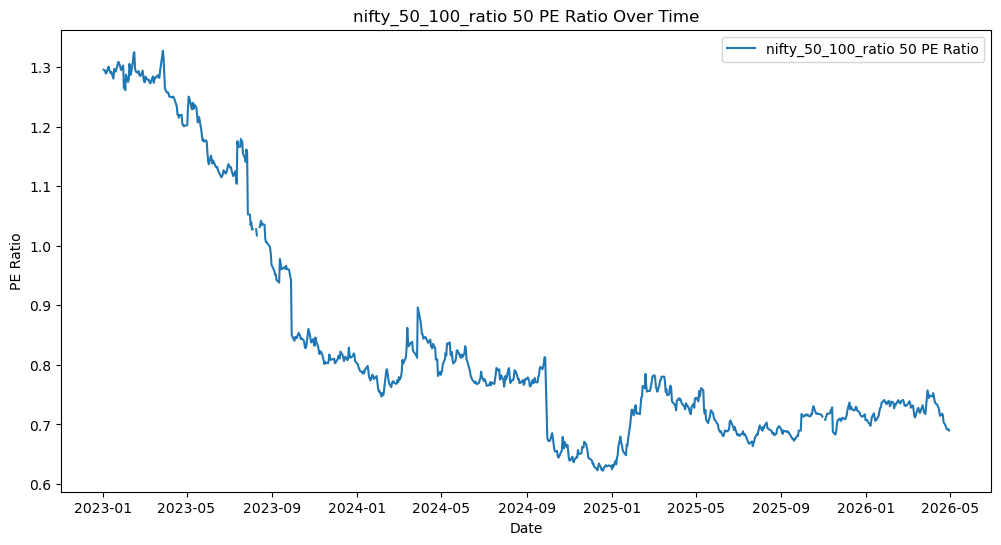

In [34]:
fig = plt.figure(figsize=(12, 6))
plt.plot(nifty_50_100_ratio.index, nifty_50_100_ratio.values, label='nifty_50_100_ratio 50 PE Ratio')
plt.xlabel('Date')
plt.ylabel('PE Ratio')
plt.title('nifty_50_100_ratio 50 PE Ratio Over Time')
plt.legend()

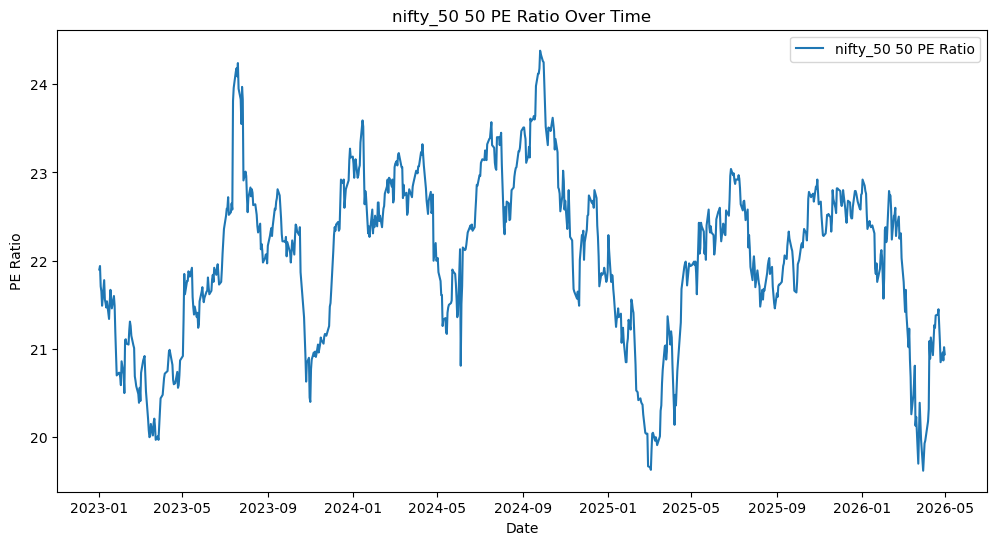

In [36]:
fig = plt.figure(figsize=(12, 6))
plt.plot(nifty_50.index, nifty_50.values, label='nifty_50 50 PE Ratio')
plt.xlabel('Date')
plt.ylabel('PE Ratio')
plt.title('nifty_50 50 PE Ratio Over Time')
plt.legend()

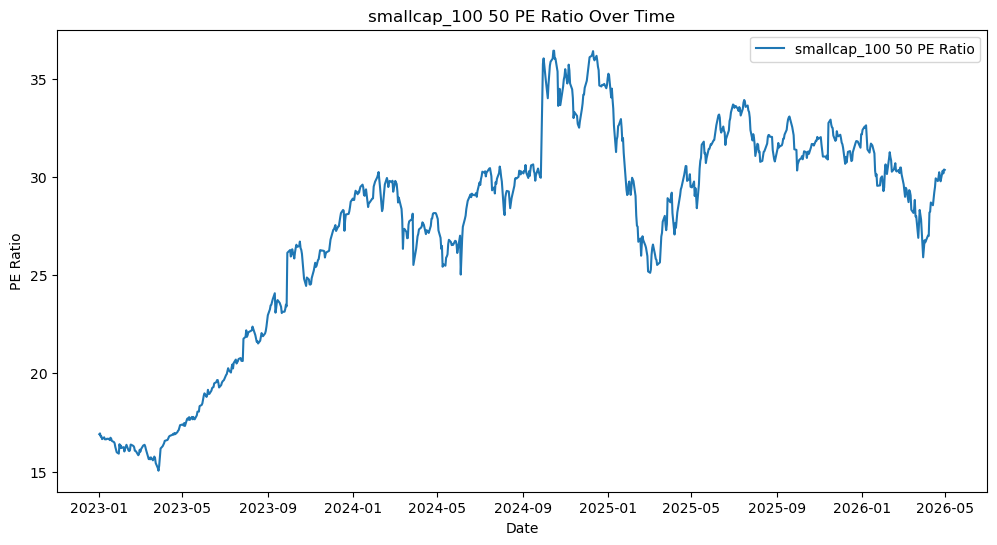

In [37]:
fig = plt.figure(figsize=(12, 6))
plt.plot(smallcap_100.index, smallcap_100.values, label='smallcap_100 50 PE Ratio')
plt.xlabel('Date')
plt.ylabel('PE Ratio')
plt.title('smallcap_100 50 PE Ratio Over Time')
plt.legend()

In [2]:
import torch
from transformers import TimesFm2_5ModelForPrediction

model = TimesFm2_5ModelForPrediction.from_pretrained("google/timesfm-2.5-200m-transformers")
model = model.to(torch.float32).eval()

past_values = [
    torch.linspace(0, 1, 100),
    torch.sin(torch.linspace(0, 20, 67)),
]

with torch.no_grad():
    outputs = model(past_values=past_values, forecast_context_len=1024)

print(outputs.mean_predictions.shape)
print(outputs.full_predictions.shape)


config.json:   0%|          | 0.00/914 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

torch.Size([2, 128])
torch.Size([2, 128, 10])


In [3]:
outputs

TimesFm2_5OutputForPrediction(last_hidden_state=tensor([[[ 9.5159e+00, -7.6483e-02,  5.1896e+00,  ...,  3.1021e+00,
          -6.2024e+00, -5.9184e+00],
         [ 9.5159e+00, -7.6483e-02,  5.1896e+00,  ...,  3.1021e+00,
          -6.2024e+00, -5.9184e+00],
         [ 9.5159e+00, -7.6483e-02,  5.1896e+00,  ...,  3.1021e+00,
          -6.2024e+00, -5.9184e+00],
         ...,
         [ 2.2934e-01, -7.0823e-01,  1.3728e+00,  ..., -6.9388e-01,
          -8.3889e-02,  7.2799e-01],
         [-1.0031e+00,  3.4221e-01, -3.8368e-02,  ..., -6.4394e-01,
          -3.8831e-01,  1.4781e-01],
         [-4.4242e-01,  1.7973e-01, -1.9465e-01,  ..., -1.4966e-01,
          -3.2401e-01, -8.4679e-03]],

        [[ 9.5159e+00, -7.6483e-02,  5.1896e+00,  ...,  3.1021e+00,
          -6.2024e+00, -5.9184e+00],
         [ 9.5159e+00, -7.6483e-02,  5.1896e+00,  ...,  3.1021e+00,
          -6.2024e+00, -5.9184e+00],
         [ 9.5159e+00, -7.6483e-02,  5.1896e+00,  ...,  3.1021e+00,
          -6.2024e+00, -5.91